# 02 – Exploratory Data Analysis

**Data Exploration**: Begin by exploring the dataset to understand its structure, features, and any patterns present in the data. Identify relevant features that could influence the close price of a property.

**Goal:** understand the data to predict a property's ClosePrice.

**Scope**
- Source: `CRMLSSoldYYYYMM*.csv`, `CRMLSSoldYYYYMM*_fill.csv`
- Time window: at least 6 months (`2024/01 - 2025/01`)
- Filter: `PropertyType == "Residential"` and `PropertySubType == "SingleFamilyResidence"`

**Variables explored** ClosePrice, LivingArea, LotSizeSquareFeet, BedroomsTotal, BathroomsTotalInteger

## 1. Setup

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.options.display.float_format = "{:,.2f}".format

DATA_DIR = Path("../raw-data/csv") # folder with the CRMLS csv files
START, END = "2024-01", "2025-01"

PROPERTY_TYPE = "Residential"
PROPERTY_SUBTYPE = "SingleFamilyResidence"

TARGET = "ClosePrice"
FEATURES = ["LivingArea", "LotSizeSquareFeet", "BedroomsTotal", "BathroomsTotalInteger"]
ALL_NUM = [TARGET] + FEATURES

SEED = 42

## 2. Load and filter the data

For each month in the window we:
1. find the matching file (`CRMLSSold{YYYYMM}*.csv`). For each month, there exists either the standard version or the `_filled` version;
2. drop the columns `latfilled` / `lonfilled` that only shows up in `_filled` version so every every month has identical columns;
3. keep only Residential / SingleFamilyResidence rows;
4. record how many rows each step kept

In [36]:
months = pd.date_range(START, END, freq="MS").strftime("%Y%m")

frames, load_log = [], []
for ym in months:
    file_path = next(DATA_DIR.glob(f"CRMLSSold{ym}*.csv"), None)
    
    if file_path is None:
        print(f"Warning: no file found for {ym}")
        continue

    month_df = pd.read_csv(file_path, low_memory=False)
    month_df = month_df.drop(columns=["latfilled", "lonfilled"], errors="ignore")

    is_target_type = (month_df["PropertyType"] == PROPERTY_TYPE) & (month_df["PropertySubType"] == PROPERTY_SUBTYPE)
    load_log.append({
        "month": ym, 
        "file": file_path.name,
        "rows_in_file": len(month_df), 
        "rows_after_filter": int(is_target_type.sum())
    })
    frames.append(month_df[is_target_type])

raw_df = pd.concat(frames, ignore_index=True)
load_summary = pd.DataFrame(load_log)
display(load_summary)
print(f"\nCombined shape: {raw_df.shape}  |  kept {len(raw_df):,} of {load_summary['rows_in_file'].sum():,} rows "
      f"({len(raw_df) / load_summary['rows_in_file'].sum():.1%})")

,month,file,rows_in_file,rows_after_filter
0,202401,CRMLSSold202401_filled.csv,17958,8322
1,202402,CRMLSSold202402.csv,19925,9564
2,202403,CRMLSSold202403_filled.csv,23276,11634
3,202404,CRMLSSold202404_filled.csv,24640,12745
4,202405,CRMLSSold202405_filled.csv,26487,13831
5,202406,CRMLSSold202406_filled.csv,24328,12545
6,202407,CRMLSSold202407_filled.csv,26240,13378
7,202408,CRMLSSold202408.csv,24558,12433
8,202409,CRMLSSold202409.csv,21267,10909
9,202410,CRMLSSold202410.csv,23274,12347



Combined shape: (147168, 80)  |  kept 147,168 of 291,211 rows (50.5%)


### quick peak of the data

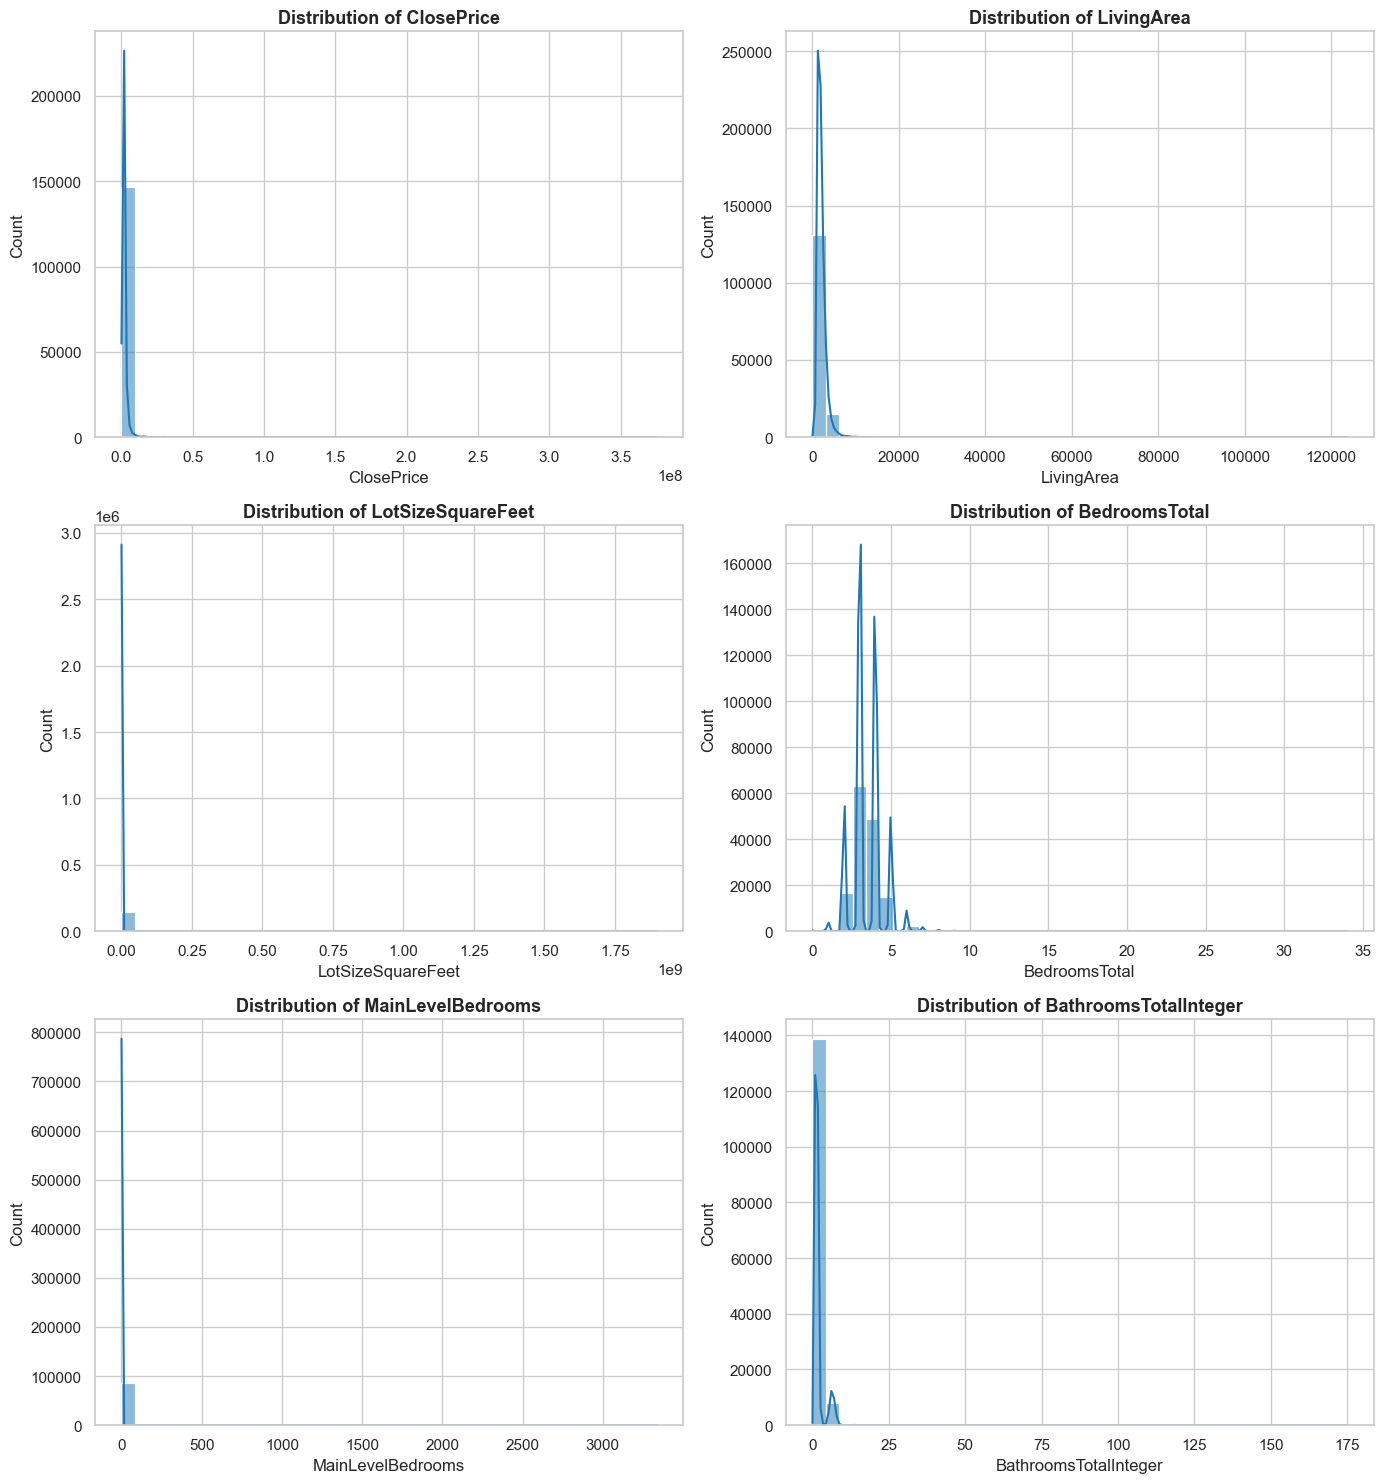

In [39]:
import math

all_variables = [TARGET] + FEATURES
n_features = len(all_variables)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(14, 5 * n_rows)
)
axes = axes.flatten()  # simple 1D indexing, works for any grid shape

for i, variable in enumerate(all_variables):
    sns.histplot(
        data=df,
        x=variable,
        kde=True,
        color="#1f77b4",
        ax=axes[i],
        bins=40
    )
    axes[i].set_title(
        f"Distribution of {variable}",
        fontsize=13,
        fontweight="bold"
    )
    axes[i].set_xlabel(variable)

plt.tight_layout()
plt.show()

## 3. Data quality

In [37]:
df = raw_df.copy()

# turn columns all to numeric
for col in ALL_NUM:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Dates became datetime
df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")

### 3.1 Missing values

In [38]:
missing = (df[ALL_NUM].isna().sum().to_frame("missing_count")
    .assign(missing_pct=lambda t: 100 * t["missing_count"] / len(df)))
display(missing)

,missing_count,missing_pct
ClosePrice,2,0.00
LivingArea,79,0.05
LotSizeSquareFeet,2494,1.69
BedroomsTotal,0,0.00
MainLevelBedrooms,61107,41.52
BathroomsTotalInteger,31,0.02


### 3.2 Extreme values in the raw data

In [14]:
quantiles = df[ALL_NUM].quantile([0, 0.001, 0.01, 0.25, 0.5, 0.75, 0.99, 0.999, 1]).T
quantiles.columns = [f"{q:.1%}" for q in quantiles.columns]
display(quantiles)

,0.0%,0.1%,1.0%,25.0%,50.0%,75.0%,99.0%,99.9%,100.0%
ClosePrice,1.15,"95,000.00","239,000.00","625,000.00","899,000.00","1,450,000.00","6,000,635.80","16,000,000.00","375,000,000.00"
LivingArea,100.00,480.00,726.00,"1,368.00","1,791.00","2,404.00","5,647.00","10,000.00","123,764.00"
BedroomsTotal,0.00,1.00,2.00,3.00,3.00,4.00,6.00,8.00,34.00
BathroomsTotalInteger,0.00,1.00,1.00,2.00,2.00,3.00,6.00,10.00,175.00
LotSizeSquareFeet,0.01,854.20,"1,872.00","5,663.00","7,212.00","10,189.00","239,513.46","2,549,538.05","1,897,473,600.00"


## 4. Cleaning

In [ ]:
# FEATURES = ["LivingArea", "LotSizeSquareFeet", "BedroomsTotal", "BathroomsTotalInteger"]

def iqr_fences(s, factor=3.0, log=False):
    """Return (lower, upper) outlier fences in the original units."""
    s = s.dropna()
    s = s[s > 0]
    x = np.log(s) if log else s
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - factor * iqr, q3 + factor * iqr
    return (np.exp(lo), np.exp(hi)) if log else (lo, hi)

FACTOR = 3.0   # 3.0 = "far" outliers

# statistical iqr formula
price_lo, price_hi = iqr_fences(df["ClosePrice"], FACTOR, log=True)
area_lo, area_hi = iqr_fences(df["LivingArea"], FACTOR, log=True)
lot_lo, lot_hi = iqr_fences(df["LotSizeSquareFeet"],    FACTOR, log=True)
bed_lo, bed_hi = iqr_fences(df["BedroomsTotal"],   FACTOR)
bath_lo, bath_hi = iqr_fences(df["BathroomsTotalInteger"],  FACTOR)

MIN_PRICE = price_lo
MAX_PRICE = price_hi
LIVING_AREA_RANGE = (area_lo, area_hi)
BEDROOM_RANGE = (max(1, int(np.floor(bed_lo))),  int(np.ceil(bed_hi)))
BATHROOM_RANGE = (max(1, int(np.floor(bath_lo))), int(np.ceil(bath_hi)))
MAX_LOT_SQFT = lot_hi 

In [42]:
clean = df.copy()

clean = clean[clean[TARGET].notna()]
clean = clean[clean[TARGET] >= MIN_PRICE]
clean = clean[clean["LivingArea"].isna() | clean["LivingArea"].between(*LIVING_AREA_RANGE)]
clean = clean[clean["BedroomsTotal"].isna() | clean["BedroomsTotal"].between(*BEDROOM_RANGE)]
clean = clean[clean["BathroomsTotalInteger"].isna() | clean["BathroomsTotalInteger"].between(*BATHROOM_RANGE)]
clean = clean[clean["LotSizeSquareFeet"].isna() | (clean["LotSizeSquareFeet"] <= MAX_LOT_SQFT)]

Summary statistics after cleaning

In [58]:
display(clean[ALL_NUM].describe().T)

,count,mean,std,min,25%,50%,75%,max
ClosePrice,"139,908.00","1,203,448.04","1,614,856.67","50,500.00","625,000.00","890,000.00","1,420,000.00","375,000,000.00"
LivingArea,"139,850.00","1,955.03",849.15,288.00,"1,357.00","1,768.00","2,358.00","10,500.00"
LotSizeSquareFeet,"137,445.00","9,234.82","7,817.93",0.00,"5,600.00","7,056.00","9,550.00","59,293.00"
BedroomsTotal,"139,908.00",3.45,0.89,1.00,3.00,3.00,4.00,7.00
MainLevelBedrooms,"81,607.00",2.30,11.91,0.00,1.00,3.00,3.00,"3,333.00"
BathroomsTotalInteger,"139,878.00",2.54,0.97,1.00,2.00,2.00,3.00,6.00


## 5. Distributions

### 5.1 ClosePrice

House prices is right-skewed a log transform usually makes the shape closer to symmetric, which helps linear models. Note that some ML models such as tree-based models do not need it.

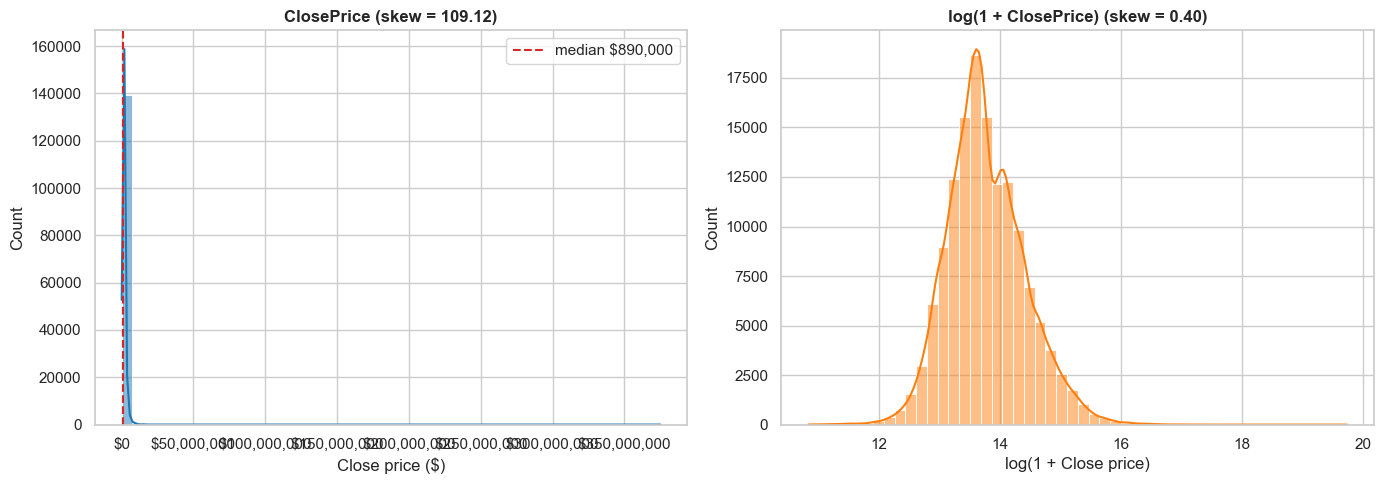

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(clean[TARGET], bins=50, kde=True, color="#1f77b4", ax=axes[0])
axes[0].set_title(f"ClosePrice (skew = {clean[TARGET].skew():.2f})", fontweight="bold")
axes[0].set_xlabel("Close price ($)")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
axes[0].axvline(clean[TARGET].median(), color="#d62728", ls="--", label=f"median ${clean[TARGET].median():,.0f}")
axes[0].legend()

log_price = np.log1p(clean[TARGET])
sns.histplot(log_price, bins=50, kde=True, color="#ff7f0e", ax=axes[1])
axes[1].set_title(f"log(1 + ClosePrice) (skew = {log_price.skew():.2f})", fontweight="bold")
axes[1].set_xlabel("log(1 + Close price)")

plt.tight_layout()
plt.show()

### 5.2 `LivingArea` and `LotSizeSquareFeet`

both of them are continuous data

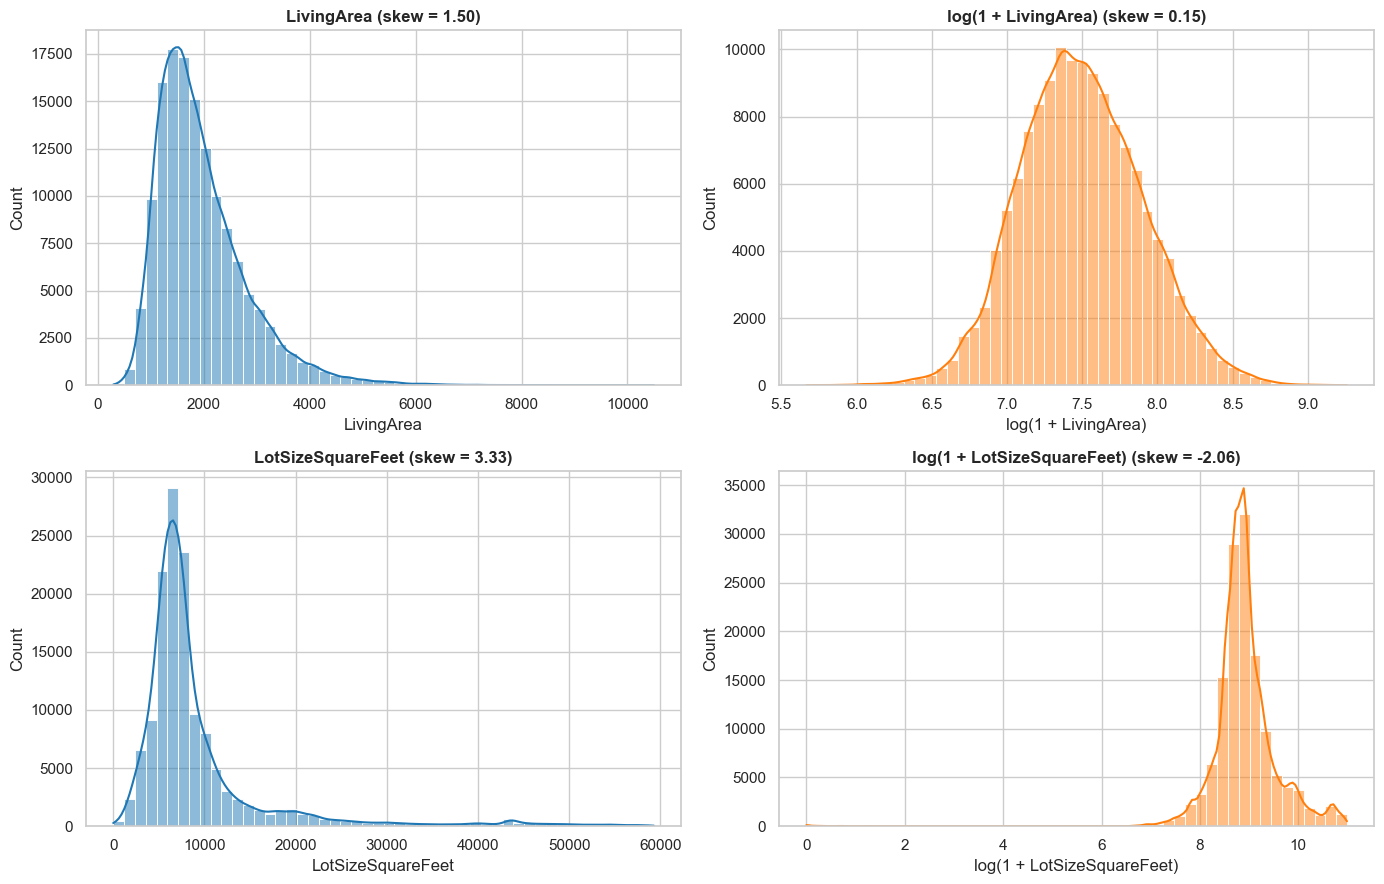

In [45]:
cont_features = ["LivingArea", "LotSizeSquareFeet"]
fig, axes = plt.subplots(len(cont_features), 2, figsize=(14, 4.5 * len(cont_features)))

for i, col in enumerate(cont_features):
    values = clean[col].dropna()
    sns.histplot(values, bins=50, kde=True, color="#1f77b4", ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} (skew = {values.skew():.2f})", fontweight="bold")
    axes[i, 0].set_xlabel(col)

    log_values = np.log1p(values)
    sns.histplot(log_values, bins=50, kde=True, color="#ff7f0e", ax=axes[i, 1])
    axes[i, 1].set_title(f"log(1 + {col}) (skew = {log_values.skew():.2f})", fontweight="bold")
    axes[i, 1].set_xlabel(f"log(1 + {col})")

plt.tight_layout()
plt.show()

### 5.3 BedroomsTotal and BathroomsTotalInteger

Discrete features

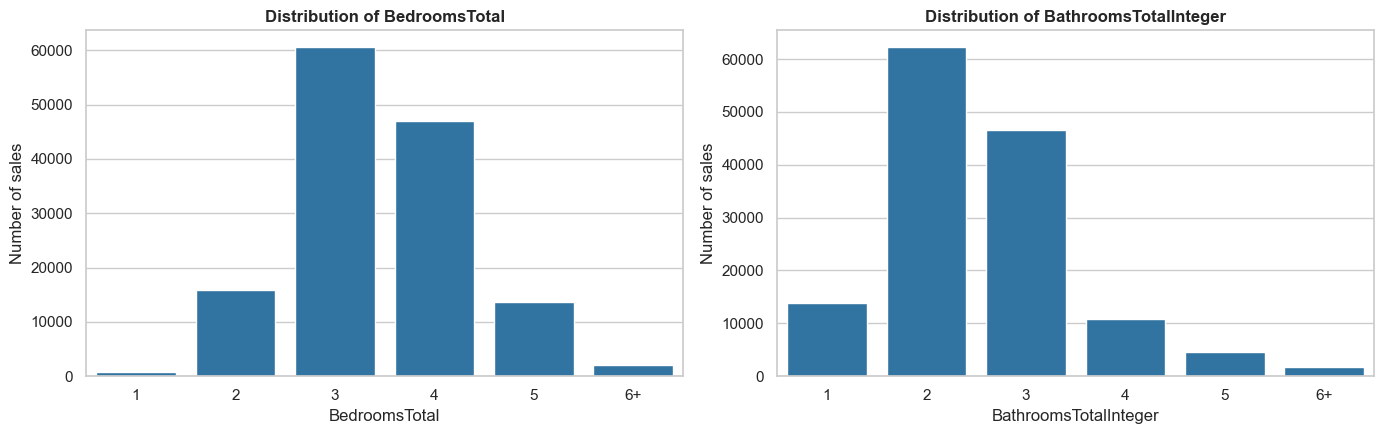

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, col in zip(axes, ["BedroomsTotal", "BathroomsTotalInteger"]):
    grouped = clean[col].dropna().clip(upper=6).astype(int)
    order = sorted(grouped.unique())
    sns.countplot(x=grouped, order=order, color="#1f77b4", ax=ax)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f"{v}+" if v == 6 else str(v) for v in order])
    ax.set_title(f"Distribution of {col}", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of sales")

plt.tight_layout()
plt.show()

## 6. Relationships with ClosePrice

### 6.1 Price by bedroom and bathroom count

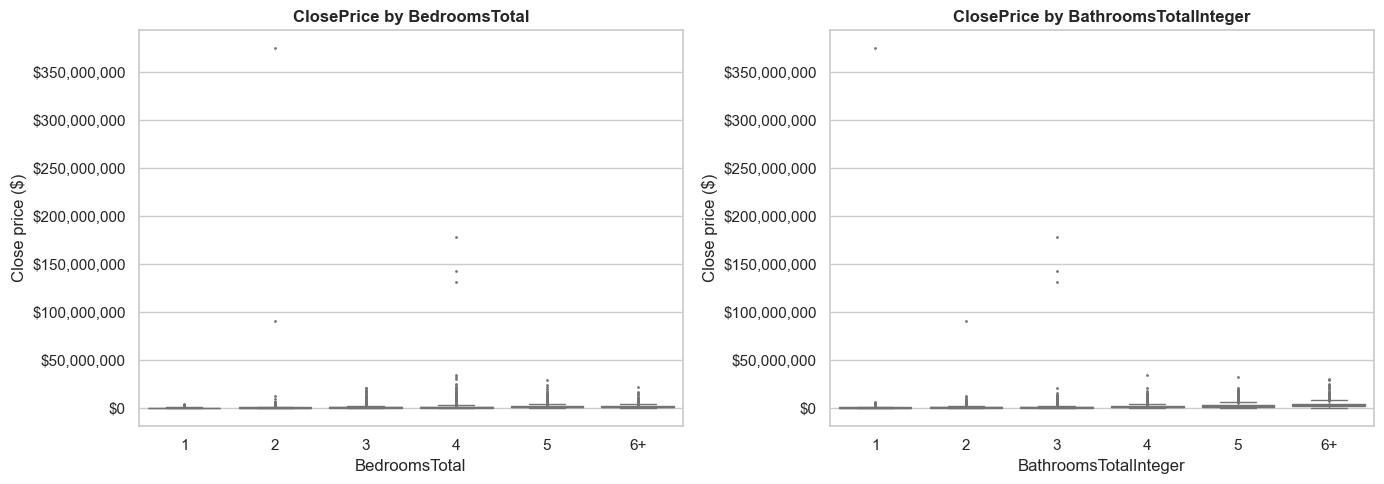

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ["BedroomsTotal", "BathroomsTotalInteger"]):
    sub = clean.dropna(subset=[col]).copy()
    sub["group"] = sub[col].clip(upper=6).astype(int)
    order = sorted(sub["group"].unique())
    sns.boxplot(data=sub, x="group", y=TARGET, order=order, color="#9ecae1", fliersize=1, ax=ax)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f"{v}+" if v == 6 else str(v) for v in order])
    ax.set_title(f"ClosePrice by {col}", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Close price ($)")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

plt.tight_layout()
plt.show()

exclude the outliers

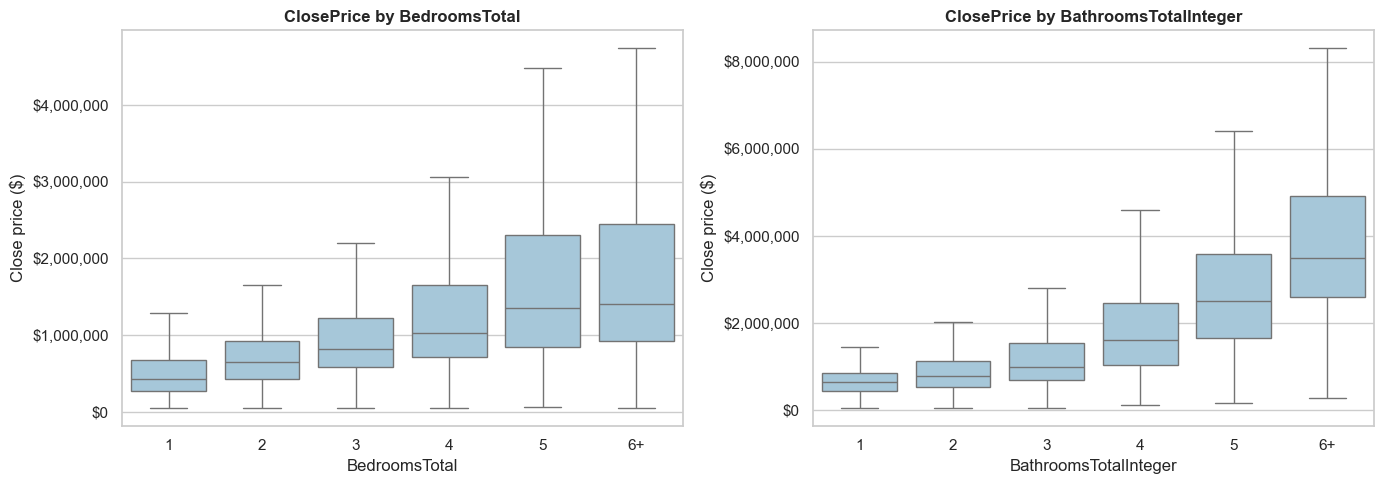

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ["BedroomsTotal", "BathroomsTotalInteger"]):
    sub = clean.dropna(subset=[col]).copy()
    sub["group"] = sub[col].clip(upper=6).astype(int)
    order = sorted(sub["group"].unique())
    
    # Set showfliers=False to hide outlier dots
    sns.boxplot(data=sub, x="group", y=TARGET, order=order, color="#9ecae1", showfliers=False, ax=ax)
    
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f"{v}+" if v == 6 else str(v) for v in order])
    ax.set_title(f"ClosePrice by {col}", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Close price ($)")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

plt.tight_layout()
plt.show()

### 6.2 Scatter plots with a trend line

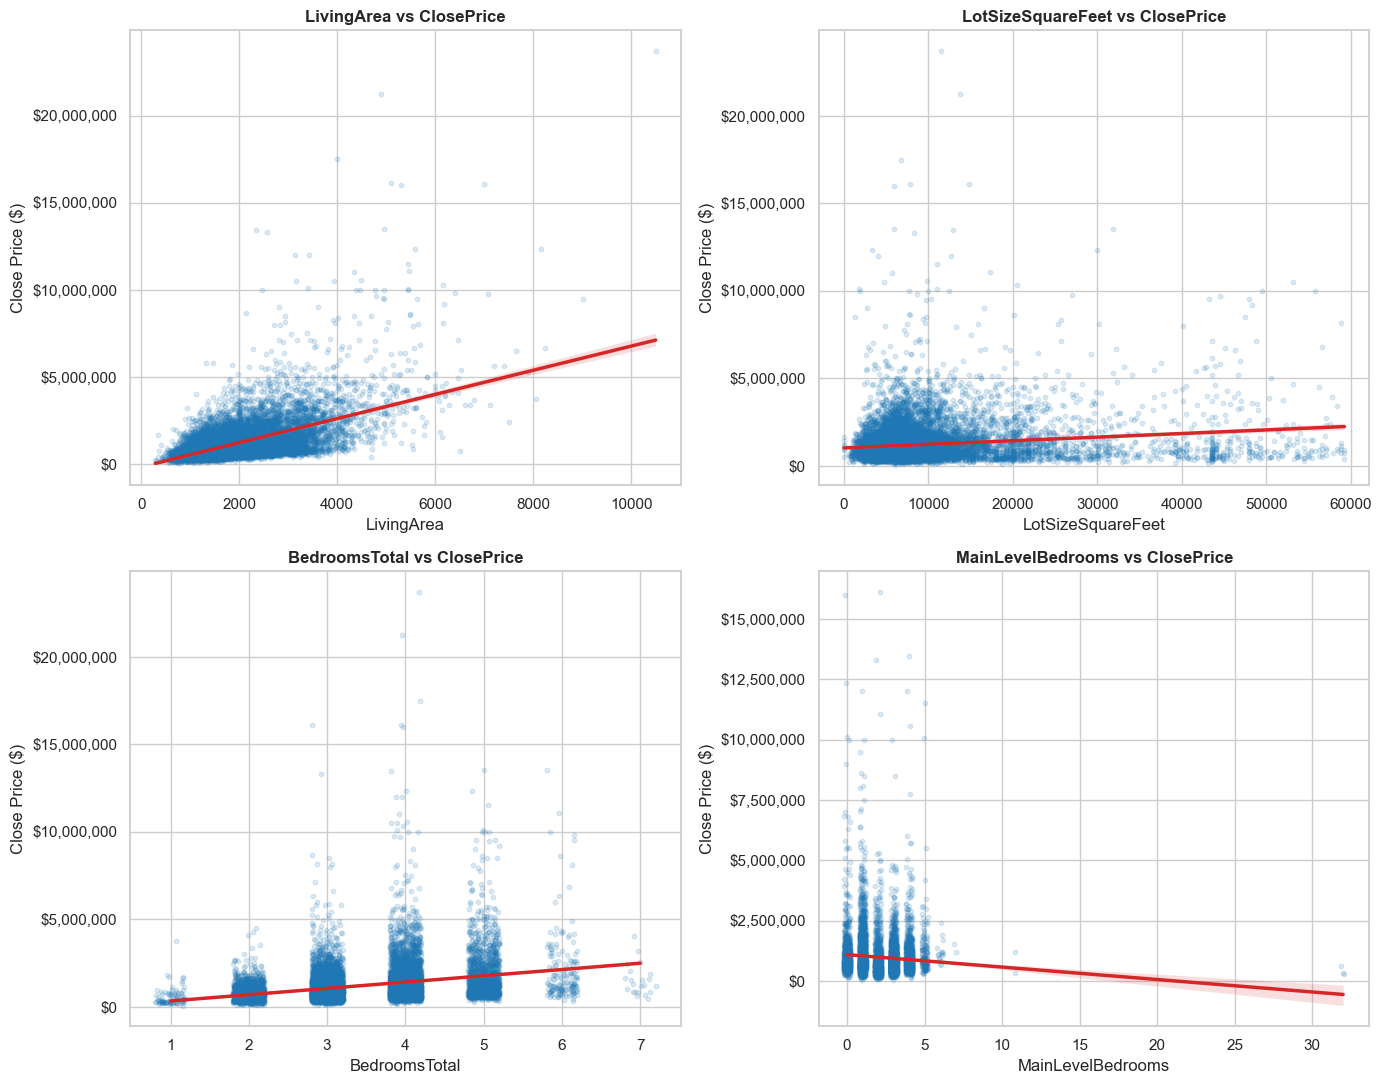

In [53]:
sample = clean.sample(n=min(15_000, len(clean)), random_state=SEED).copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, col in zip(axes.flatten(), FEATURES):
    sub = sample.dropna(subset=[col, TARGET])
    sns.regplot(
        data=sub, x=col, y=TARGET, ax=ax, x_jitter=0.2, ci=95,
        scatter_kws={"alpha": 0.15, "s": 10, "color": "#1f77b4"},
        line_kws={"color": "#d62728", "linewidth": 2.5},
    )
    ax.set_title(f"{col} vs ClosePrice", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Close Price ($)")
    
    # Format y-axis as dollar values with commas
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))


plt.tight_layout()
plt.show()

/opt/miniconda3/envs/py_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


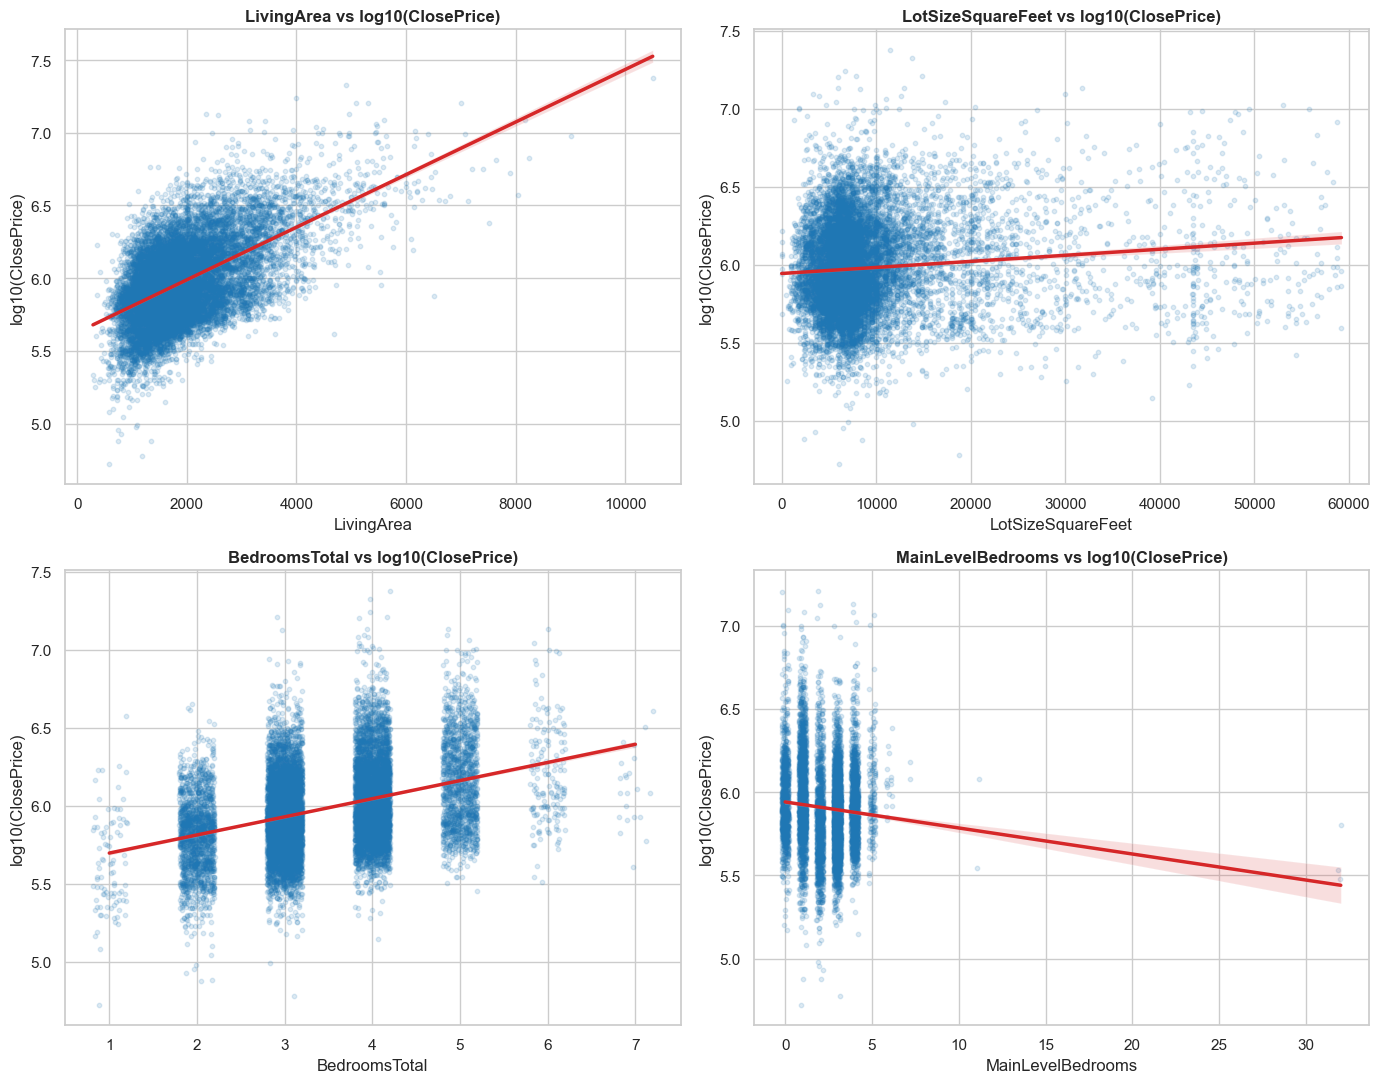

In [54]:
sample = clean.sample(n=min(15_000, len(clean)), random_state=SEED).copy()
sample["log10_ClosePrice"] = np.log10(sample[TARGET])
sample["log10_LivingArea"] = np.log10(sample["LivingArea"])
sample["log10_LotSizeSquareFeet"] = np.log10(sample["LotSizeSquareFeet"])


fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, col in zip(axes.flatten(), FEATURES):
    sub = sample.dropna(subset=[col])
    sns.regplot(
        data=sub, x=col, y="log10_ClosePrice", ax=ax, x_jitter=jitter, ci=95,
        scatter_kws={"alpha": 0.15, "s": 10, "color": "#1f77b4"},
        line_kws={"color": "#d62728", "linewidth": 2.5},
    )
    ax.set_title(f"{col} vs log10(ClosePrice)", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("log10(ClosePrice)")

plt.tight_layout()
plt.show()

## 7. Correlations, time trend and geography

### 7.1 Correlation heatmap

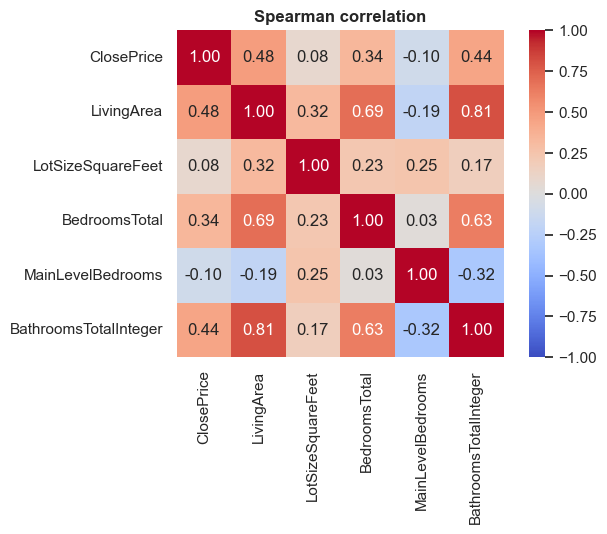

In [55]:
corr = clean[ALL_NUM].corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Spearman correlation", fontweight="bold")
plt.tight_layout()
plt.show()

### 7.2 Monthly trend

Does the market move over time?

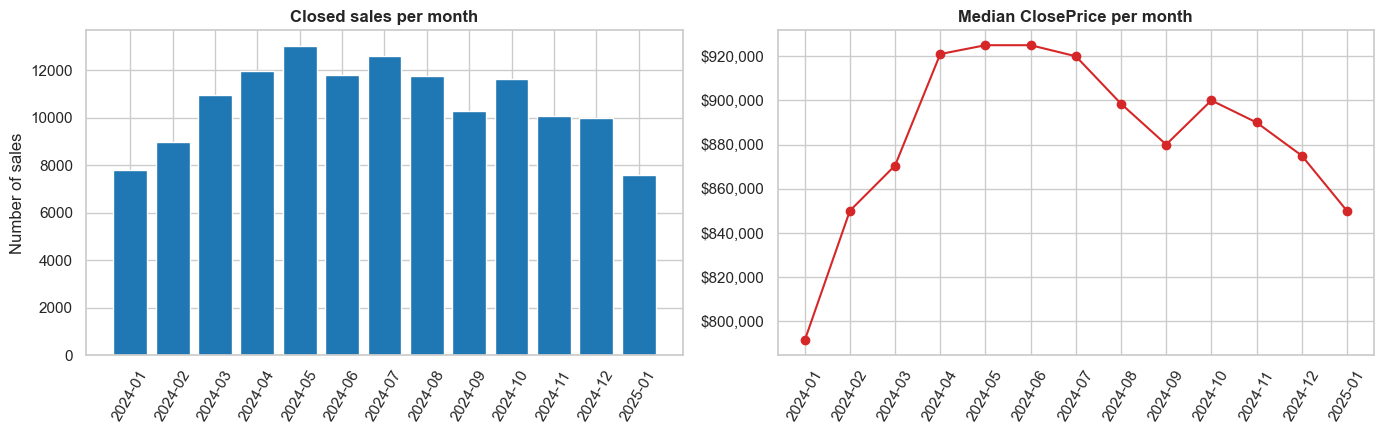

In [34]:
monthly = (clean.dropna(subset=["CloseDate"])
           .groupby(clean["CloseDate"].dt.to_period("M"))[TARGET]
           .agg(sales="size", median_price="median"))
monthly.index = monthly.index.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(monthly.index, monthly["sales"], color="#1f77b4")
axes[0].set_title("Closed sales per month", fontweight="bold")
axes[0].set_ylabel("Number of sales")

axes[1].plot(monthly.index, monthly["median_price"], marker="o", color="#d62728")
axes[1].set_title("Median ClosePrice per month", fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

for ax in axes:
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

### 7.3 Geography

Location is usually one of the strongest drivers of price

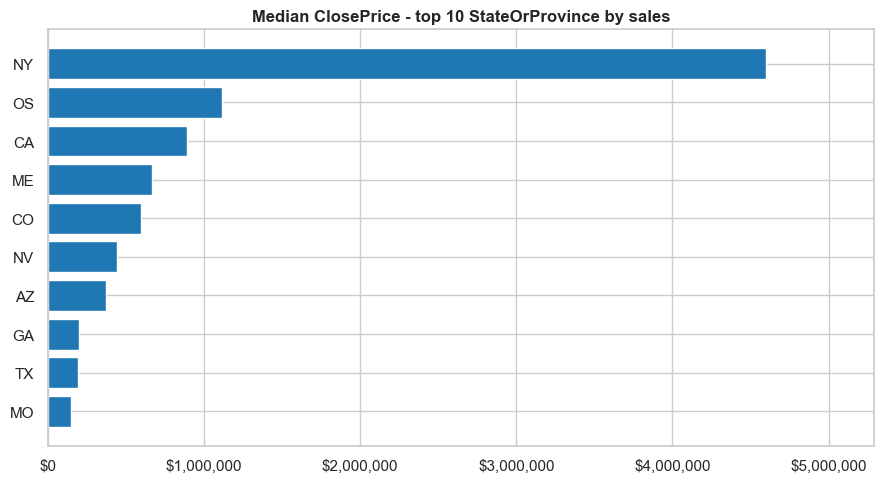

In [57]:
geo_col = 'StateOrProvince'

top_areas = clean[geo_col].value_counts().head(10).index
area_stats = (clean[clean[geo_col].isin(top_areas)]
                .groupby(geo_col)[TARGET].agg(sales="size", median_price="median")
                .sort_values("median_price"))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(area_stats.index.astype(str), area_stats["median_price"], color="#1f77b4")

ax.set_title(f"Median ClosePrice - top 10 {geo_col} by sales", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.margins(x=0.15)
plt.tight_layout()
plt.show()